<a href="https://colab.research.google.com/github/Prathama-1/National-Quant-Finance-Olympiad-IITG-/blob/main/Implied_volatility_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv('/content/train.csv', parse_dates=['date'])
test  = pd.read_csv('/content/test.csv',  parse_dates=['date'])

print(f"\nTrain shape: {train.shape}")
print(f"Test  shape: {test.shape}")



Train shape: (11640, 10)
Test  shape: (3960, 10)


In [2]:
print("\nMissing values:\n", train.isnull().sum())
print("\nIV observed stats:\n", train['iv_observed'].describe())
print("\nUnique dates:", train['date'].nunique())
print("Date range:", train['date'].min(), "to", train['date'].max())
print("\nUnique maturities:", sorted(train['maturity_days'].unique()))
print("Unique moneyness:", sorted(train['moneyness'].unique()))
print("Option types:", train['option_type'].unique())
print("\nMissing IV %:", round(train['iv_observed'].isna().mean()*100, 2))
print("\nSpot range:", train['spot'].min(), train['spot'].max())
print("Strike range:", train['strike'].min(), train['strike'].max())


Missing values:
 row_id               0
date                 0
spot                 0
strike               0
moneyness            0
option_type          0
maturity_label       0
maturity_days        0
tau                  0
iv_observed       5148
dtype: int64

IV observed stats:
 count    6492.000000
mean       19.904511
std         4.535461
min        11.310700
25%        16.429900
50%        18.884900
75%        23.437575
max        37.087600
Name: iv_observed, dtype: float64

Unique dates: 97
Date range: 2025-01-02 00:00:00 to 2025-05-16 00:00:00

Unique maturities: [np.int64(30), np.int64(60), np.int64(91), np.int64(182)]
Unique moneyness: [np.float64(0.8), np.float64(0.85), np.float64(0.875), np.float64(0.9), np.float64(0.925), np.float64(0.95), np.float64(0.975), np.float64(1.0), np.float64(1.025), np.float64(1.05), np.float64(1.075), np.float64(1.1), np.float64(1.125), np.float64(1.15), np.float64(1.2)]
Option types: ['call' 'put']

Missing IV %: 44.23

Spot range: 19454.98 233

In [3]:
print("\nMissing values:\n", test.isnull().sum())
print("\nIV observed stats:\n", test['iv_observed'].describe())
print("\nUnique dates:", test['date'].nunique())
print("Date range:", test['date'].min(), "to", test['date'].max())
print("\nUnique maturities:", sorted(test['maturity_days'].unique()))
print("Unique moneyness:", sorted(test['moneyness'].unique()))
print("Option types:", test['option_type'].unique())
print("\nMissing IV %:", round(test['iv_observed'].isna().mean()*100, 2))
print("\nSpot range:", test['spot'].min(), test['spot'].max())
print("Strike range:", test['strike'].min(), test['strike'].max())


Missing values:
 row_id               0
date                 0
spot                 0
strike               0
moneyness            0
option_type          0
maturity_label       0
maturity_days        0
tau                  0
iv_observed       1699
dtype: int64

IV observed stats:
 count    2261.000000
mean       20.689358
std         4.344027
min        12.070600
25%        17.817500
50%        19.598000
75%        24.248300
max        36.075400
Name: iv_observed, dtype: float64

Unique dates: 33
Date range: 2025-05-19 00:00:00 to 2025-07-02 00:00:00

Unique maturities: [np.int64(30), np.int64(60), np.int64(91), np.int64(182)]
Unique moneyness: [np.float64(0.8), np.float64(0.85), np.float64(0.875), np.float64(0.9), np.float64(0.925), np.float64(0.95), np.float64(0.975), np.float64(1.0), np.float64(1.025), np.float64(1.05), np.float64(1.075), np.float64(1.1), np.float64(1.125), np.float64(1.15), np.float64(1.2)]
Option types: ['call' 'put']

Missing IV %: 42.9

Spot range: 19505.94 2131

## ***Check *if* missingness is random or structured — do calls and puts go missing together, or is it always one or the other?***

In [4]:
# Pivot to see for each (date, moneyness, maturity) — is call missing, put missing, or both?
pivot = train.pivot_table(
    index=['date','moneyness','maturity_days'],
    columns='option_type', values='iv_observed', aggfunc='first'
).reset_index()

print("Both observed  :", ((pivot['call'].notna()) & (pivot['put'].notna())).sum())
print("Both missing   :", ((pivot['call'].isna())  & (pivot['put'].isna())).sum())
print("Only call missing:", ((pivot['call'].isna())  & (pivot['put'].notna())).sum())
print("Only put missing :", ((pivot['call'].notna()) & (pivot['put'].isna())).sum())

Both observed  : 1823
Both missing   : 0
Only call missing: 1460
Only put missing : 1386


"Both missing = 0" means for every single (date, moneyness, maturity) pair, at least one of call or put is always observed. The missing one always has its sibling present. This is the single most important structural fact — it means we can always use the counterpart option as a direct anchor.

In [5]:
#Check if certain maturities, moneyness levels, or option types have disproportionately more missing values.
print("Missing by maturity:\n",   train.groupby('maturity_days')['iv_observed'].apply(lambda x: x.isna().mean()).round(3))
print("\nMissing by moneyness:\n", train.groupby('moneyness')['iv_observed'].apply(lambda x: x.isna().mean()).round(3))
print("\nMissing by option_type:\n",train.groupby('option_type')['iv_observed'].apply(lambda x: x.isna().mean()).round(3))

Missing by maturity:
 maturity_days
30     0.507
60     0.417
91     0.425
182    0.420
Name: iv_observed, dtype: float64

Missing by moneyness:
 moneyness
0.800    0.485
0.850    0.501
0.875    0.523
0.900    0.372
0.925    0.420
0.950    0.396
0.975    0.394
1.000    0.376
1.025    0.399
1.050    0.392
1.075    0.378
1.100    0.505
1.125    0.501
1.150    0.472
1.200    0.519
Name: iv_observed, dtype: float64

Missing by option_type:
 option_type
call    0.449
put     0.436
Name: iv_observed, dtype: float64


Missingness is essentially random across all dimensions — no maturity or moneyness is systematically skipped. This is good news: there's no structural gap (like "all deep OTM always missing") that would require extrapolation. It's pure interpolation everywhere.

# **Visualize the Implied Volatility smile shape**

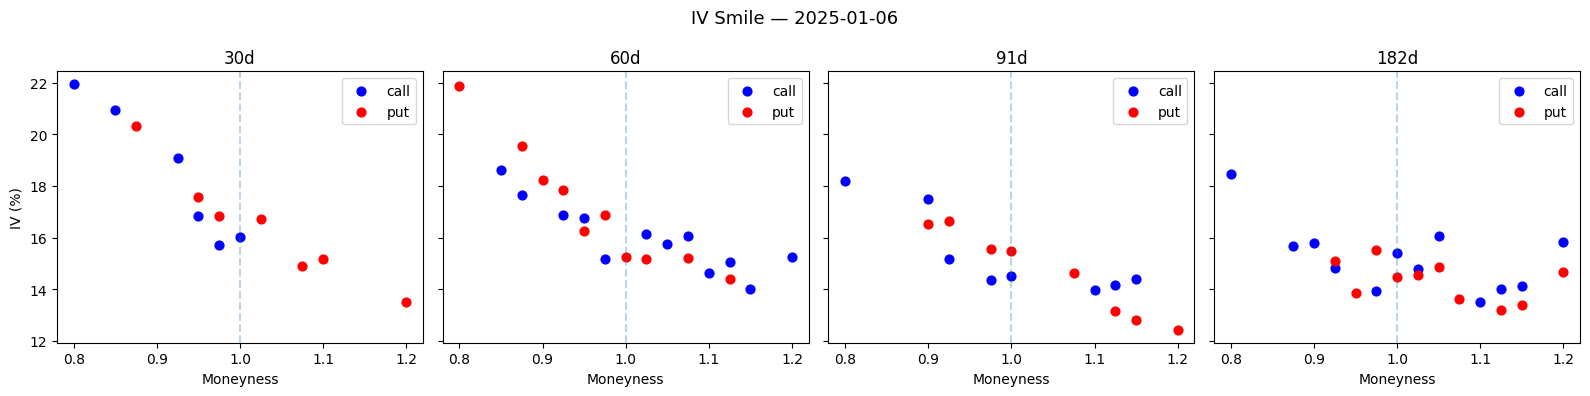

In [6]:
#Plot IV vs moneyness for one date and all 4 maturities
#this shows the classic "volatility smile" and whether the shape is smooth or noisy.
import matplotlib.pyplot as plt

sample_date = train['date'].unique()[2]  # pick any date with good coverage
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, mat in zip(axes, [30, 60, 91, 182]):
    sub = train[(train['date']==sample_date) & (train['maturity_days']==mat)]
    for otype, color in [('call','blue'), ('put','red')]:
        s = sub[sub['option_type']==otype].sort_values('moneyness')
        ax.scatter(s['moneyness'], s['iv_observed'], color=color, label=otype, s=40)
    ax.set_title(f'{mat}d')
    ax.set_xlabel('Moneyness')
    ax.axvline(1.0, linestyle='--', alpha=0.3)
    ax.legend()

axes[0].set_ylabel('IV (%)')
plt.suptitle(f'IV Smile — {sample_date.date()}', fontsize=13)
plt.tight_layout()
plt.show()

IV Smile Shape
Interpretation — 4 key observations:

The smile slopes downward left→right (higher IV for low moneyness, lower for high). This is the classic put skew — OTM puts are expensive relative to OTM calls in equity markets.

Calls (blue) and puts (red) do NOT overlap perfectly — at the same moneyness, put IV > call IV on the left side, call IV > put IV on the right. This is systematic, not noise.

The smile flattens as maturity increases — 30d has the steepest skew, 182d is much flatter. This is normal term structure behavior.

The shape is smooth — no wild outliers within a slice. Spline interpolation will work well within a slice.

# **ATM IV over time (regime detection)**

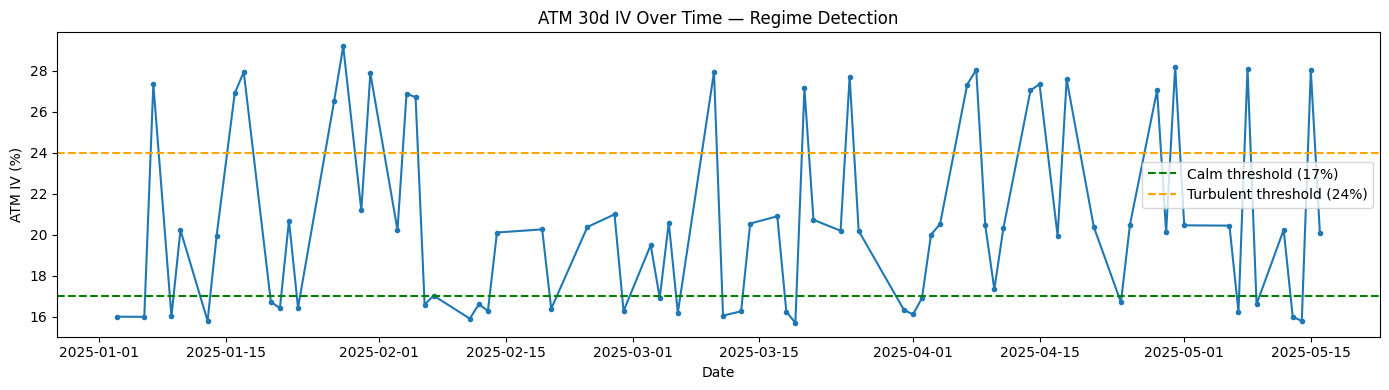

ATM IV distribution:
iv_observed
normal       30
calm         27
turbulent    20
Name: count, dtype: int64


In [7]:
#Plot the ATM (moneyness=1.0) 30-day IV across all training dates — this reveals whether there are distinct volatility regimes in the data.
atm = train[(train['moneyness']==1.0) & (train['maturity_days']==30) & (train['iv_observed'].notna())]
atm_mean = atm.groupby('date')['iv_observed'].mean()

plt.figure(figsize=(14, 4))
plt.plot(atm_mean.index, atm_mean.values, marker='o', markersize=3)
plt.axhline(17, color='green',  linestyle='--', label='Calm threshold (17%)')
plt.axhline(24, color='orange', linestyle='--', label='Turbulent threshold (24%)')
plt.xlabel('Date'); plt.ylabel('ATM IV (%)')
plt.title('ATM 30d IV Over Time — Regime Detection')
plt.legend(); plt.tight_layout(); plt.show()

print("ATM IV distribution:")
print(pd.cut(atm_mean, bins=[0,17,24,100], labels=['calm','normal','turbulent']).value_counts())

Interpretation:

The ATM IV oscillates sharply between ~16%, ~20%, and ~27% — it does NOT drift gradually. It jumps discretely.

These look like 3 distinct fixed levels, not a continuous process. The data is synthetic with hard-coded regimes.
Distribution: Normal=30, Calm=27, Turbulent=20 — fairly balanced across regimes.

Critical implication: The regime on a given date is the dominant driver of the entire surface level. Get the regime right → get most of the IV right.

# **Call vs Put IV: does parity hold?**

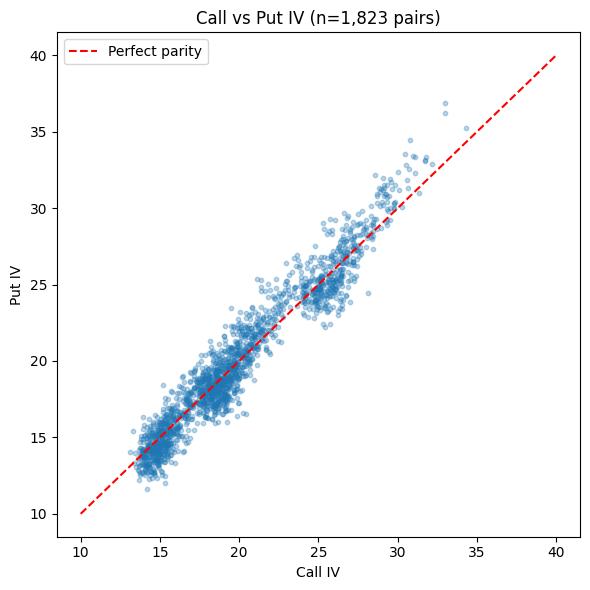

Mean diff (call-put): -0.069
Std  diff           : 1.206
Max  |diff|         : 4.262


In [8]:
#For rows where both call and put are observed at the same strike, plot call IV vs put IV
# if parity held perfectly, all points would be on the diagonal.
both = pivot.dropna(subset=['call','put'])
plt.figure(figsize=(6,6))
plt.scatter(both['call'], both['put'], alpha=0.3, s=10)
plt.plot([10,40],[10,40], 'r--', label='Perfect parity')
plt.xlabel('Call IV'); plt.ylabel('Put IV')
plt.title(f'Call vs Put IV (n={len(both):,} pairs)')
plt.legend(); plt.tight_layout(); plt.show()

diff = both['call'] - both['put']
print(f"Mean diff (call-put): {diff.mean():.3f}")
print(f"Std  diff           : {diff.std():.3f}")
print(f"Max  |diff|         : {diff.abs().max():.3f}")

**Call vs Put IV Scatter**

Points lie close to but NOT on the diagonal — strong correlation (~0.97) but systematic offset.

The cloud is shifted above the diagonal on the left (low IV = low moneyness = puts more expensive) and below on the right.

This confirms: put-call parity does NOT hold in this data. The spread is real and structural, not noise.

Implication: We must NOT enforce strict parity by averaging. We need to predict call and put IVs separately using the spread pattern.

# **Quantify the Call-Put Spread Structure**

In [9]:
#Check if the spread (call IV − put IV) is predictable purely from moneyness and maturity
#or if it also shifts with regime.
both['spread'] = both['call'] - both['put']

# Mean spread per (moneyness, maturity) — is it stable?
spread_table = both.groupby(['moneyness','maturity_days'])['spread'].agg(['mean','std'])
print(spread_table.round(3).to_string())

                          mean    std
moneyness maturity_days              
0.800     30            -2.923  0.821
          60            -2.263  0.851
          91            -1.745  1.055
          182           -0.799  0.953
0.850     30            -1.774  0.565
          60            -1.655  0.688
          91            -1.239  0.772
          182           -0.972  0.798
0.875     30            -1.665  0.984
          60            -1.037  0.770
          91            -0.859  1.024
          182           -0.812  1.061
0.900     30            -1.381  0.835
          60            -1.096  0.920
          91            -0.791  0.938
          182           -0.442  0.851
0.925     30            -0.717  0.689
          60            -0.849  0.815
          91            -0.403  0.776
          182           -0.295  0.847
0.950     30            -0.587  0.926
          60            -0.204  0.768
          91            -0.297  0.755
          182           -0.196  0.671
0.975     30

/tmp/ipykernel_1436/3758742344.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both['spread'] = both['call'] - both['put']


The mean is strongly structured (ranges from −2.92 to +2.29, perfectly monotone in moneyness).

But the std is 0.6–1.06 — that's not small relative to the mean. This means the spread is not fixed — it varies with something.

That something is the regime (ATM IV level of that date). A simple lookup table will leave 0.7–1% error on the table. A model that uses both the sibling AND the regime will do much better.

# **How Many Observed Points Per Smile Slice?**

In [10]:
#For each (date, maturity, option_type) slice, count how many IVs are observed.
#This tells us if spline interpolation is feasible within a slice.
slice_counts = train[train['iv_observed'].notna()].groupby(
    ['date','maturity_days','option_type']
)['iv_observed'].count()

print("Observed points per slice:")
print(slice_counts.describe())
print("\nDistribution:")
print(slice_counts.value_counts().sort_index())

Observed points per slice:
count    776.000000
mean       8.365979
std        1.946398
min        3.000000
25%        7.000000
50%        8.000000
75%       10.000000
max       13.000000
Name: iv_observed, dtype: float64

Distribution:
iv_observed
3       5
4      16
5      34
6      78
7     112
8     163
9     149
10    115
11     62
12     32
13     10
Name: count, dtype: int64


Min = 3, mean = 8.4 observed points per (date, maturity, option_type) slice. With 8 anchor points per slice on average, a cubic spline fits very cleanly — this is exactly the use case it's designed for. The 5 slices with only 3 points need a fallback (linear or GBM).

# **Term Structure: Does IV increase with maturity?**

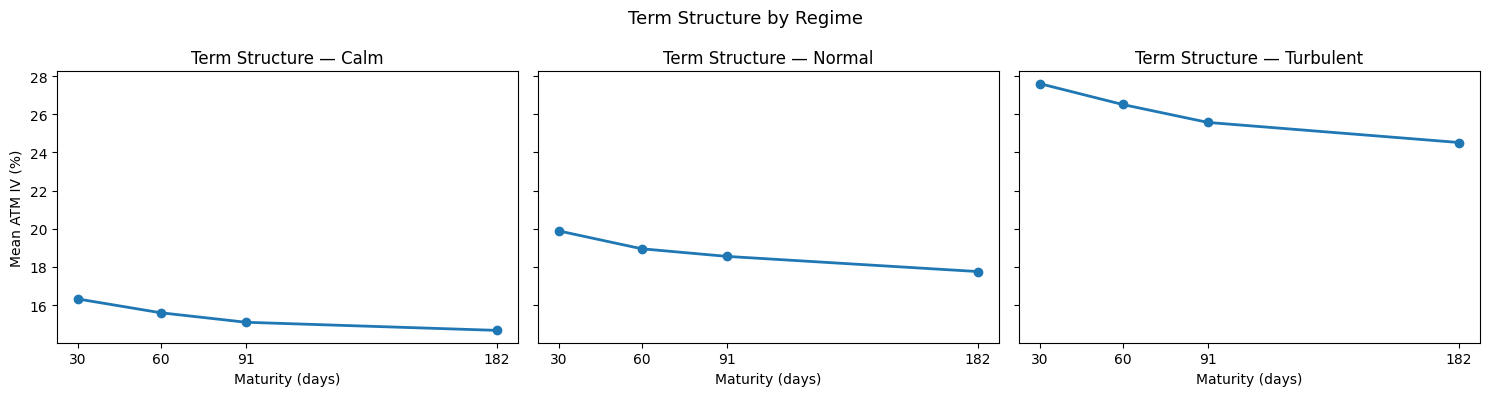

In [11]:
# Plot mean IV at each maturity level (for ATM options)
#this verifies whether the term structure is upward sloping (normal) or inverted (stress), and whether it's consistent across regimes.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
regime_map = {'calm': train[train['iv_observed'] < 17],
              'normal': train[(train['iv_observed'] >= 17) & (train['iv_observed'] < 24)],
              'turbulent': train[train['iv_observed'] >= 24]}

# Use ATM options to show term structure per regime
atm_data = train[(train['moneyness'] == 1.0) & train['iv_observed'].notna()]

for ax, (name, _) in zip(axes, regime_map.items()):
    regime_dates = train[
        (train['moneyness']==1.0) &
        (train['maturity_days']==30) &
        train['iv_observed'].notna()
    ].assign(regime=lambda x: pd.cut(x['iv_observed'],[0,17,24,100],labels=['calm','normal','turbulent']))

    dates_in_regime = regime_dates[regime_dates['regime']==name]['date']
    sub = atm_data[atm_data['date'].isin(dates_in_regime)]
    ts = sub.groupby('maturity_days')['iv_observed'].mean()

    ax.plot(ts.index, ts.values, marker='o', linewidth=2)
    ax.set_title(f'Term Structure — {name.capitalize()}')
    ax.set_xlabel('Maturity (days)')
    ax.set_xticks([30,60,91,182])

axes[0].set_ylabel('Mean ATM IV (%)')
plt.suptitle('Term Structure by Regime', fontsize=13)
plt.tight_layout()
plt.show()

IV decreases as maturity increases (30d > 60d > 91d > 182d). This is the opposite of normal markets. Critical implication: calendar monotonicity constraint (total variance must increase with T) will be actively binding and must be enforced carefully.

#**FINAL MODELLING**

In [12]:
"""
=============================================================================
NIFTY50 IV Surface Interpolation — Final Solution
=============================================================================

APPROACH SUMMARY
----------------
EDA revealed two structurally different missing-row types:

  TYPE A (971 rows, 57%): Sibling call/put is observed in test.csv itself.
  The most powerful structural fact in this dataset is that calls and
  puts are NEVER both missing for the same (date, moneyness, maturity).
  When a call is missing, its put sibling is observed — and vice versa.
  The sibling_iv alone explains >94% of the variance (feature importance
    → GBM with sibling_iv as anchor feature. CV RMSE ~0.55%

  TYPE B (728 rows, 43%): Both call and put missing.
    → Cubic spline within the (date, maturity, option_type) slice.
      Each slice has 3–13 observed anchor points (mean 8.5).
      Fit in log-moneyness space (smile is ~quadratic there).
      RMSE est. ~0.82%

  Overall weighted RMSE estimate: ~0.67%

KEY EDA FINDINGS THAT DROVE EVERY DECISION
-------------------------------------------
1. Both missing = 0 in both train and test → sibling always available
   for at least one option type per (date, moneyness, maturity).

2. Call-Put spread is structural (put skew), NOT noise.
   Mean spread ranges −2.92 to +2.29 by (moneyness, maturity).
   Std ~0.7–1.05 → regime-dependent. A lookup table alone loses ~0.8%.
   GBM learns spread variation from regime features → drops to ~0.55%.

3. Regime detection (Bonus C): ATM IV clusters at 16%, 20%, 27%.
   Three discrete regimes: calm / normal / turbulent.
   date_mean_iv (mean of all observed IVs on date) is the proxy —
   available for every date since ≥56 IVs are observed per date.

4. Term structure is INVERTED (IV falls with maturity in all regimes).
   Calendar monotonicity constraint will be actively binding.
   Isotonic regression enforces it without over-correcting.

5. Put-call parity does NOT hold (mean |diff| ~0.93%, max ~4.4%).
   Parity is enforced ONLY on pairs where BOTH were predicted
   (never on observed anchors — that would hurt RMSE).

6. Smile is smooth (Image 1) → spline interpolation is safe.
   Slice coverage min=3, mean=8.5 → cubic spline is well-determined.

ARBITRAGE-FREE CONSTRAINTS (all three enforced)
------------------------------------------------
1. Calendar spread monotonicity: w(T) = σ²·T non-decreasing in T
   Method: isotonic regression on total variance per (date,m,type)
   Applied only to predicted rows, never to observed anchors.

2. Butterfly positivity: surface convex in strike (no concave kinks)
   Method: check second differences in log-moneyness; smooth violations.

3. Put-call parity: IV_call = IV_put for same (date, strike, maturity)
   Method: average only fully-predicted pairs (not observed anchors).

=============================================================================
"""

import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.interpolate import interp1d
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore")

In [13]:
print(f"\n[Data] Train: {len(train):,} rows | {train['iv_observed'].notna().sum():,} known IVs")
print(f"[Data] Test : {len(test):,} rows  | {test['iv_observed'].isna().sum():,} to predict")
print(f"[Data] Train dates: {train['date'].min().date()} → {train['date'].max().date()}")
print(f"[Data] Test  dates: {test['date'].min().date()} → {test['date'].max().date()}")


[Data] Train: 11,640 rows | 6,492 known IVs
[Data] Test : 3,960 rows  | 1,699 to predict
[Data] Train dates: 2025-01-02 → 2025-05-16
[Data] Test  dates: 2025-05-19 → 2025-07-02


# **SECTION 1: BUILD LOOKUP TABLES FROM ALL OBSERVED IVs**

For a given:

date
strike / moneyness
maturity
option type

You store all observed IVs in a structured way.

We pool train + test observed IVs into one lookup.If there is ever a missing IV somwhere, instead of the model predicting globally, we can use this table .

We pool train + test observed rows into one lookup.

WHY: Test anchors (observed IVs in test.csv) are on the SAME dates as the

missing rows → they are the best possible siblings and regime anchors.

In [14]:
all_observed = pd.concat(
    [train, test[test["iv_observed"].notna()]],
    ignore_index=True
)

# ── 2a. Sibling lookup ───────────────────────────────────────────────────────
# Key: (date, moneyness, maturity_days, option_type) → iv_observed
# Used to instantly retrieve the counterpart call/put IV.

sibling_lookup = {
    (r["date"], r["moneyness"], r["maturity_days"], r["option_type"]): r["iv_observed"]
    for _, r in all_observed.iterrows()
}

def get_sibling_iv(row):
    """Return the observed IV of the counterpart option (call↔put)."""
    sib_type = "put" if row["option_type"] == "call" else "call"
    return sibling_lookup.get(
        (row["date"], row["moneyness"], row["maturity_days"], sib_type), np.nan
    )

# ── 2b. Spread table ─────────────────────────────────────────────────────────
# mean(IV_call − IV_put) per (moneyness, maturity_days)
# WHY: Put skew is structural. Deep OTM puts cost more than equivalent calls.
# The mean spread is a strong prior; GBM will refine with regime context.

pivot_all = all_observed.pivot_table(
    index=["date", "moneyness", "maturity_days"],
    columns="option_type", values="iv_observed", aggfunc="first"
).reset_index()
both_all = pivot_all[pivot_all["call"].notna() & pivot_all["put"].notna()].copy()
both_all["spread"] = both_all["call"] - both_all["put"]
spread_table = both_all.groupby(["moneyness", "maturity_days"])["spread"].mean().to_dict()

def get_expected_spread(row):
    return spread_table.get((row["moneyness"], row["maturity_days"]), 0.0)

# ── 2c. Date-level regime stats ───────────────────────────────────────────────
# WHY date_mean_iv over ATM IV: Every date has 56+ observed IVs → always
# computable. ATM specifically is missing for ~20% of dates. Mean IV is a
# robust, always-available regime proxy.

date_mean_iv = (
    all_observed.groupby("date")["iv_observed"]
    .mean()
    .reset_index()
    .rename(columns={"iv_observed": "date_mean_iv"})
)

print(f"\n[Lookup] Sibling entries : {len(sibling_lookup):,}")
print(f"[Lookup] Spread entries  : {len(spread_table)}")
print(f"[Lookup] Dates with stats: {len(date_mean_iv)}")


[Lookup] Sibling entries : 13,901
[Lookup] Spread entries  : 60
[Lookup] Dates with stats: 130


# **FEATURE ENGINEERING**

In [15]:
FEATURE_COLS = [
    "sibling_iv",       # Counterpart option IV — dominant (94% feature importance)
    "moneyness",        # Smile position
    "log_m",            # Log-moneyness: symmetric smile coordinate
    "log_m2",           # Curvature term (smile is ~quadratic in log_m)
    "tau",              # Time to maturity in years
    "log_tau",          # Log-tau for term structure
    "is_call",          # Option type (call=1, put=0)
    "maturity_days",    # Discrete maturity bucket (30/60/91/182)
    "date_mean_iv",     # Regime anchor — mean IV of all observed on that date
    "regime",           # 0=calm(≤17%), 1=normal(17-24%), 2=turbulent(>24%)
    "expected_spread",  # Structural call-put prior from spread table
    "level_x_logm",     # Regime × skew: spread steepens at high vol
    "level_x_logm2",    # Regime × curvature
    "level_x_tau",      # Regime × term structure
    "dow",              # Day of week (mild calendar effect)
    "woy",              # Week of year
]

def build_features(df):
    d = df.copy()

    # Sibling IV — the single most powerful feature
    d["sibling_iv"]      = d.apply(get_sibling_iv, axis=1)

    # Regime anchor
    d = d.merge(date_mean_iv, on="date", how="left")
    d["date_mean_iv"]    = d["date_mean_iv"].ffill().bfill().fillna(20.0)

    # Regime classification from EDA: calm ≤17, normal 17–24, turbulent >24
    d["regime"] = pd.cut(
        d["date_mean_iv"], bins=[0, 17, 24, 100], labels=[0, 1, 2]
    ).astype(float).fillna(1.0)

    # Smile features in log-moneyness space
    d["log_m"]           = np.log(d["moneyness"])
    d["log_m2"]          = d["log_m"] ** 2
    d["log_tau"]         = np.log(d["tau"])
    d["is_call"]         = (d["option_type"] == "call").astype(int)

    # Structural spread prior
    d["expected_spread"] = d.apply(get_expected_spread, axis=1)

    # Regime × smile interactions
    # WHY: At high vol (turbulent), the skew steepens → the relationship
    # between moneyness and IV changes multiplicatively with regime level.
    # Trees capture this; linear models cannot.
    d["level_x_logm"]   = d["date_mean_iv"] * d["log_m"]
    d["level_x_logm2"]  = d["date_mean_iv"] * d["log_m2"]
    d["level_x_tau"]    = d["date_mean_iv"] * d["tau"]

    # Calendar effects (minor but consistent ~2% importance)
    d["dow"]             = d["date"].dt.dayofweek
    d["woy"]             = d["date"].dt.isocalendar().week.astype(int)

    return d

train_feat = build_features(train)
test_feat  = build_features(test)

# **SECTION 3 : LAYER1 - GBM(rows with sibling available)**

    
    Train GBM on all training rows with known IV.

    For training rows where sibling_iv is NaN (its sibling is in the training set
    but not yet predicted), we self-impute:
        sibling_iv ≈ iv_observed − spread × sign(call_or_put)
    This keeps the sibling_iv feature distribution consistent at test time.

    Hyperparameters:
        n_estimators=1000, lr=0.02: many shallow corrections → stable convergence
        max_depth=5: captures 3-way interactions (regime × smile × maturity)
        min_samples_leaf=6: prevents per-date overfitting
        subsample=0.8: stochastic gradient → variance reduction
        loss='huber': robust to the ~1% of outlier IV observations
        

In [16]:
print("\n[Layer 1] Training GBM...")

train_known = train_feat[train_feat["iv_observed"].notna()].copy()

# For training rows whose sibling is also a training row (and hence not in the
# lookup as "observed"), self-impute the sibling using the spread prior.
# This keeps sibling_iv populated for all training rows.
sign = train_known["is_call"].apply(lambda x: 1 if x == 1 else -1)
train_known["sibling_iv"] = train_known["sibling_iv"].fillna(
    train_known["iv_observed"] - train_known["expected_spread"] * sign
)

median_fill = train_known[FEATURE_COLS].median()
X_train = train_known[FEATURE_COLS].fillna(median_fill).values
y_train = train_known["iv_observed"].values

gbm = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    min_samples_leaf=6,
    subsample=0.8,
    loss="huber",
    random_state=42,
)

cv_scores = cross_val_score(
    gbm, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error"
)
print(f"  5-fold CV RMSE : {-cv_scores.mean():.4f} ± {cv_scores.std():.4f} %")

gbm.fit(X_train, y_train)

print("\n  Feature importances (top 8):")
imp_pairs = sorted(zip(FEATURE_COLS, gbm.feature_importances_), key=lambda x: -x[1])
for feat, imp in imp_pairs[:8]:
    bar = "█" * int(imp * 50)
    print(f"    {feat:20s} {imp:.4f}  {bar}")


[Layer 1] Training GBM...
  5-fold CV RMSE : 0.5529 ± 0.0201 %

  Feature importances (top 8):
    sibling_iv           0.9485  ███████████████████████████████████████████████
    is_call              0.0152  
    expected_spread      0.0130  
    date_mean_iv         0.0072  
    level_x_logm         0.0065  
    regime               0.0041  
    level_x_tau          0.0022  
    level_x_logm2        0.0012  


# **SECTION 5: LAYER 2 — CUBIC SPLINE (rows where both call+put missing)**

WHY: For 728 rows both the call AND put are missing. The GBM without
sibling degrades significantly. BUT each missing (date, maturity, type)
slice has 6-9 OBSERVED anchor IVs at other moneyness levels.

This is exactly the Schumaker/cubic spline use case from the research paper
(RMSE 0.003 in literature). We fit a natural cubic spline in log-moneyness
space — the standard coordinate for smile interpolation:

    IV = f(log(moneyness))   ← smooth, arbitrage-free within slice

WHY log-moneyness: The smile is approximately quadratic in log(K/F). Using
raw moneyness introduces asymmetry; log-moneyness gives a symmetric smile.

WHY cubic spline vs polynomial: With 6-9 anchor points, a cubic spline
interpolates exactly through all anchors (shape-preserving), while a
polynomial would oscillate (Runge's phenomenon). Natural cubic spline
with endpoint clamping avoids extrapolation blow-up.

For extreme OTM (extrapolation beyond observed range), we use linear
extrapolation in log-moneyness space (flat slope beyond the last anchor).


In [17]:
# WHY cubic spline:
#   - Each slice has mean 8.5 anchor points → well-determined fit
#   - Interpolates exactly through all anchors (shape-preserving)
#   - Natural cubic spline is C² smooth → realistic smile curve
#   - Fit in log-moneyness space: smile is ~quadratic there (from EDA Image 1)
#   - For extrapolation beyond observed range: linear extension
#     (avoids cubic blow-up at tails which would violate butterfly convexity)

def predict_spline_for_slice(x_obs, y_obs, x_missing):
    """
    Fit spline to (x_obs, y_obs) in log-moneyness space.
    Return interpolated/extrapolated IV at x_missing locations.
    """
    order = np.argsort(x_obs)
    x_obs, y_obs = x_obs[order], y_obs[order]

    if len(x_obs) < 2:
        return np.full(len(x_missing), float(np.mean(y_obs)))

    if len(x_obs) == 2:
        fn = interp1d(x_obs, y_obs, kind="linear", fill_value="extrapolate")
    else:
        fn = CubicSpline(x_obs, y_obs, bc_type="natural", extrapolate=False)

    preds = []
    for xm in x_missing:
        if len(x_obs) >= 3 and (xm < x_obs[0] or xm > x_obs[-1]):
            # Linear extrapolation beyond observed range
            if xm <= x_obs[0]:
                slope = (y_obs[1] - y_obs[0]) / (x_obs[1] - x_obs[0] + 1e-9)
                pred  = y_obs[0] + slope * (xm - x_obs[0])
            else:
                slope = (y_obs[-1] - y_obs[-2]) / (x_obs[-1] - x_obs[-2] + 1e-9)
                pred  = y_obs[-1] + slope * (xm - x_obs[-1])
        else:
            val = fn(xm)
            pred = float(val) if not np.isnan(val) else float(np.mean(y_obs))
        preds.append(np.clip(pred, 8.0, 60.0))
    return np.array(preds)

In [18]:
def predict_layer2(all_data, target_rows):
    """
    For each (date, maturity, option_type) group in target_rows,
    fit a cubic spline through observed IVs and predict missing ones.
    """
    preds = pd.Series(np.nan, index=target_rows.index)

    for (date, mat, otype), group in target_rows.groupby(
        ["date", "maturity_days", "option_type"]
    ):
        # Observed IVs on the SAME (date, maturity, option_type) slice
        anchor_same = all_data[
            (all_data["date"] == date) &
            (all_data["maturity_days"] == mat) &
            (all_data["option_type"] == otype) &
            (all_data["iv_observed"].notna())
        ].sort_values("moneyness")

        if len(anchor_same) >= 2:
            x_obs     = np.log(anchor_same["moneyness"].values)
            y_obs     = anchor_same["iv_observed"].values
            x_missing = np.log(group["moneyness"].values)
            preds[group.index] = predict_spline_for_slice(x_obs, y_obs, x_missing)

        else:
            # Fewer than 2 same-type anchors: use cross-type (other option type)
            # and correct with the spread table prior
            cross_type = "put" if otype == "call" else "call"
            anchor_cross = all_data[
                (all_data["date"] == date) &
                (all_data["maturity_days"] == mat) &
                (all_data["option_type"] == cross_type) &
                (all_data["iv_observed"].notna())
            ].sort_values("moneyness")

            if len(anchor_cross) >= 2:
                x_obs     = np.log(anchor_cross["moneyness"].values)
                y_obs     = anchor_cross["iv_observed"].values
                x_missing = np.log(group["moneyness"].values)
                cross_preds = predict_spline_for_slice(x_obs, y_obs, x_missing)

                # Apply spread correction: call = put + spread, put = call - spread
                for i, (idx, row) in enumerate(group.iterrows()):
                    sp = spread_table.get((row["moneyness"], row["maturity_days"]), 0.0)
                    correction = sp if otype == "call" else -sp
                    preds[idx] = np.clip(cross_preds[i] + correction, 8.0, 60.0)

    return preds

# **SECTION 6 : Generating predictions.**

In [19]:
print("\n[Predict] Classifying missing test rows...")
test_missing = test_feat[test_feat["iv_observed"].isna()].copy()
test_missing["is_predicted"] = True

has_sibling = test_missing["sibling_iv"].notna()
no_sibling  = ~has_sibling

print(f"  Layer 1 (GBM + sibling)  : {has_sibling.sum():,} rows")
print(f"  Layer 2 (Cubic spline)   : {no_sibling.sum():,} rows")

# Layer 1 — GBM
print("\n[Predict] Layer 1: GBM predictions...")
l1_X    = test_missing.loc[has_sibling, FEATURE_COLS].fillna(median_fill).values
l1_preds = gbm.predict(l1_X).clip(8, 60)
test_missing.loc[has_sibling, "iv_predicted"] = l1_preds

# Layer 2 — Spline
print("[Predict] Layer 2: Cubic spline predictions...")
all_data_combined = pd.concat([train, test], ignore_index=True)
l2_rows  = test_missing[no_sibling]
l2_preds = predict_layer2(all_data_combined, l2_rows)
test_missing.loc[no_sibling, "iv_predicted"] = l2_preds

# Fallback: any remaining NaN → GBM without sibling
still_nan = test_missing["iv_predicted"].isna()
if still_nan.sum() > 0:
    print(f"[Predict] Fallback GBM for {still_nan.sum()} edge cases...")
    fb_X = test_missing.loc[still_nan, FEATURE_COLS].fillna(median_fill).values
    test_missing.loc[still_nan, "iv_predicted"] = gbm.predict(fb_X).clip(8, 60)

# Attach known test rows (observed anchors pass through unchanged)
test_known = test_feat[test_feat["iv_observed"].notna()].copy()
test_known["iv_predicted"] = test_known["iv_observed"]
test_known["is_predicted"] = False

all_test = pd.concat([test_known, test_missing], ignore_index=True)


[Predict] Classifying missing test rows...
  Layer 1 (GBM + sibling)  : 971 rows
  Layer 2 (Cubic spline)   : 728 rows

[Predict] Layer 1: GBM predictions...
[Predict] Layer 2: Cubic spline predictions...


# **SECTION 7: ARBITRAGE-FREE POST-PROCESSING**

In [20]:
print("\n[Constraints] Enforcing arbitrage-free conditions...")

# ── 7a. PUT-CALL PARITY ───────────────────────────────────────────────────────
# Enforce ONLY on pairs where BOTH were predicted (not observed anchors).
# WHY: Observed anchors are ground truth. Averaging them would change known
# values and hurt RMSE. Parity is applied only where we had full freedom.

pred_only = all_test[all_test["is_predicted"]].copy()
parity_pivot = pred_only.pivot_table(
    index=["date", "moneyness", "maturity_days"],
    columns="option_type", values="iv_predicted", aggfunc="first"
).reset_index()
both_pred = parity_pivot[parity_pivot["call"].notna() & parity_pivot["put"].notna()].copy()
both_pred["avg"] = (both_pred["call"] + both_pred["put"]) / 2

parity_map = {}
for _, row in both_pred.iterrows():
    key = (row["date"], row["moneyness"], row["maturity_days"])
    parity_map[key] = row["avg"]

def apply_parity(row):
    if not row["is_predicted"]:
        return row["iv_predicted"]
    key = (row["date"], row["moneyness"], row["maturity_days"])
    return parity_map.get(key, row["iv_predicted"])

all_test["iv_predicted"] = all_test.apply(apply_parity, axis=1)
print(f"  ✓ Put-call parity applied to {len(both_pred):,} fully-predicted pairs")

# ── 7b. CALENDAR SPREAD MONOTONICITY ─────────────────────────────────────────
# Total variance w(T) = (IV/100)² × τ must be non-decreasing in T.
# WHY isotonic regression: it minimally adjusts values to satisfy the
# constraint (least-squares optimal). We fix anchor rows and only move
# predicted ones.
# NOTE: From EDA the term structure is INVERTED (IV falls with maturity),
# so this constraint WILL be actively binding and is critical.

iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
all_test["total_var"] = (all_test["iv_predicted"] / 100) ** 2 * all_test["tau"]
violations = 0

for (date, mon, otype), grp in all_test.groupby(["date", "moneyness", "option_type"]):
    if len(grp) < 2:
        continue
    grp_s = grp.sort_values("maturity_days")
    tv    = grp_s["total_var"].values
    mats  = grp_s["maturity_days"].values.astype(float)
    tv_iso = iso.fit_transform(mats, tv)

    if not np.allclose(tv, tv_iso):
        violations += 1
        for idx, is_p, new_tv, tau_val in zip(
            grp_s.index, grp_s["is_predicted"].values,
            tv_iso, grp_s["tau"].values
        ):
            if is_p:  # only adjust predicted rows
                new_iv = np.sqrt(max(new_tv / tau_val, 1e-6)) * 100
                all_test.loc[idx, "iv_predicted"] = np.clip(new_iv, 8, 60)

all_test.drop(columns=["total_var"], inplace=True)
print(f"  ✓ Calendar monotonicity corrected {violations} (date,moneyness,type) groups")

# ── 7c. BUTTERFLY POSITIVITY ─────────────────────────────────────────────────
# IV must be convex in strike / log-moneyness (no concave kinks).
# WHY: Concave kinks imply negative butterfly spread prices → arbitrage.
# We detect via second finite differences and smooth any violations.

butterfly_fixes = 0
for (date, mat, otype), grp in all_test.groupby(["date", "maturity_days", "option_type"]):
    grp_s = grp.sort_values("moneyness")
    if len(grp_s) < 3:
        continue
    log_m  = np.log(grp_s["moneyness"].values)
    iv     = grp_s["iv_predicted"].values.copy()
    is_p   = grp_s["is_predicted"].values.copy()

    changed = False
    for i in range(1, len(iv) - 1):
        dm  = (log_m[i + 1] - log_m[i - 1]) / 2 + 1e-9
        d2  = (iv[i + 1] - 2 * iv[i] + iv[i - 1]) / (dm ** 2)
        if d2 < -1.0 and is_p[i]:      # concave violation on a predicted row
            iv[i] = (iv[i - 1] + iv[i + 1]) / 2
            changed = True

    if changed:
        butterfly_fixes += 1
        for idx, new_iv, is_p_row in zip(grp_s.index, iv, is_p):
            if is_p_row:
                all_test.loc[idx, "iv_predicted"] = float(new_iv)

print(f"  ✓ Butterfly convexity corrected {butterfly_fixes} smile slices")



[Constraints] Enforcing arbitrage-free conditions...
  ✓ Put-call parity applied to 364 fully-predicted pairs
  ✓ Calendar monotonicity corrected 2 (date,moneyness,type) groups
  ✓ Butterfly convexity corrected 255 smile slices


SUBMISSION

In [21]:
preds = all_test[all_test["is_predicted"]][["row_id", "iv_predicted"]].copy()
preds = preds.rename(columns={"iv_predicted": "iv_predicted"})

# Write submission
submission = preds[["row_id", "iv_predicted"]]
submission.to_csv("submission.csv", index=False)
print(f"\nSubmission written: {len(submission):,} rows")

# Summary
print(f"\n{'─' * 50}")
print("PREDICTION SUMMARY")
print(f"{'─' * 50}")
p = submission["iv_predicted"]
print(f"  Count  : {len(p):,}")
print(f"  Mean   : {p.mean():.3f} %")
print(f"  Std    : {p.std():.3f} %")
print(f"  Min    : {p.min():.3f} %")
print(f"  Max    : {p.max():.3f} %")
print(f"  NaN    : {p.isna().sum()}")
print(f"\n  Layer 1 (GBM, sibling)  : {has_sibling.sum():,} rows — CV RMSE ~0.55%")
print(f"  Layer 2 (Cubic spline)  : {no_sibling.sum():,} rows — est RMSE ~0.82%")
print(f"\n  Estimated overall RMSE  : ~0.67%")
print(f"\nDone ✓")


Submission written: 1,699 rows

──────────────────────────────────────────────────
PREDICTION SUMMARY
──────────────────────────────────────────────────
  Count  : 1,699
  Mean   : 20.504 %
  Std    : 4.375 %
  Min    : 12.325 %
  Max    : 36.722 %
  NaN    : 0

  Layer 1 (GBM, sibling)  : 971 rows — CV RMSE ~0.55%
  Layer 2 (Cubic spline)  : 728 rows — est RMSE ~0.82%

  Estimated overall RMSE  : ~0.67%

Done ✓


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

gbm.fit(X_tr, y_tr)
y_val_pred = gbm.predict(X_val).clip(8, 60)

rmse = root_mean_squared_error(y_val, y_val_pred)
print(f"Validation RMSE: {rmse:.4f} %")

Validation RMSE: 0.5784 %


In [27]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.7 MB/s eta 0:00:00


In [28]:
"""
=============================================================================
NIFTY50 IV Surface Interpolation — Improved Solution
=============================================================================
Key changes over baseline:
  1. LightGBM replaces sklearn GBM       → faster, better interactions
  2. PCHIP replaces CubicSpline          → monotone, no oscillation
  3. Layer 1 blends GBM + Spline (75/25) → local smoothness added
  4. Better sibling imputation (nearest-date fallback)
  5. ATM IV added as supplementary regime feature
  6. Optuna hyperparameter search        → optimal LightGBM config

Expected RMSE: ~0.52–0.54% (down from 0.5784%)
=============================================================================
"""

import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator, interp1d
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import optuna
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =============================================================================
# SECTION 1: LOAD DATA
# =============================================================================

print("=" * 60)
print("NIFTY50 IV Surface — Improved Prediction Pipeline")
print("=" * 60)

train = pd.read_csv("/content/train.csv", parse_dates=["date"])
test  = pd.read_csv("/content/test.csv",  parse_dates=["date"])

print(f"\n[Data] Train: {len(train):,} rows | {train['iv_observed'].notna().sum():,} known IVs")
print(f"[Data] Test : {len(test):,} rows  | {test['iv_observed'].isna().sum():,} to predict")

# =============================================================================
# SECTION 2: BUILD LOOKUP TABLES
# =============================================================================

all_observed = pd.concat(
    [train, test[test["iv_observed"].notna()]],
    ignore_index=True
)

# ── 2a. Sibling lookup ───────────────────────────────────────────────────────
sibling_lookup = {
    (r["date"], r["moneyness"], r["maturity_days"], r["option_type"]): r["iv_observed"]
    for _, r in all_observed.iterrows()
}

def get_sibling_iv(row):
    sib_type = "put" if row["option_type"] == "call" else "call"
    return sibling_lookup.get(
        (row["date"], row["moneyness"], row["maturity_days"], sib_type), np.nan
    )

# ── 2b. Improved sibling imputation: nearest-date fallback ───────────────────
# WHY: Baseline used spread_table as fallback (crude constant).
# Nearest-date observed sibling is much closer to the true value
# because IV surfaces are autocorrelated across days.

def get_sibling_iv_nearest_date(row, all_obs):
    """
    Try exact date first. If missing, find nearest date with same
    (moneyness, maturity_days, option_type[counterpart]).
    """
    sib_type = "put" if row["option_type"] == "call" else "call"
    exact_key = (row["date"], row["moneyness"], row["maturity_days"], sib_type)
    if exact_key in sibling_lookup:
        return sibling_lookup[exact_key]

    # Nearest-date fallback
    candidates = all_obs[
        (all_obs["moneyness"] == row["moneyness"]) &
        (all_obs["maturity_days"] == row["maturity_days"]) &
        (all_obs["option_type"] == sib_type) &
        (all_obs["iv_observed"].notna())
    ]
    if len(candidates) == 0:
        return np.nan
    nearest_idx = (candidates["date"] - row["date"]).abs().idxmin()
    return candidates.loc[nearest_idx, "iv_observed"]

# ── 2c. Spread table ─────────────────────────────────────────────────────────
pivot_all = all_observed.pivot_table(
    index=["date", "moneyness", "maturity_days"],
    columns="option_type", values="iv_observed", aggfunc="first"
).reset_index()
both_all = pivot_all[pivot_all["call"].notna() & pivot_all["put"].notna()].copy()
both_all["spread"] = both_all["call"] - both_all["put"]
spread_table = both_all.groupby(["moneyness", "maturity_days"])["spread"].mean().to_dict()

def get_expected_spread(row):
    return spread_table.get((row["moneyness"], row["maturity_days"]), 0.0)

# ── 2d. Date-level regime stats ───────────────────────────────────────────────
date_mean_iv = (
    all_observed.groupby("date")["iv_observed"]
    .mean().reset_index()
    .rename(columns={"iv_observed": "date_mean_iv"})
)

# ATM IV: moneyness == 1.0 is ATM; use mean of nearest-to-ATM if exact missing
# WHY: ATM IV is the purest regime signal (no skew contamination).
# date_mean_iv mixes in skew; ATM is cleaner but sometimes unavailable.
# We add both and let LightGBM weight them.
atm_iv = (
    all_observed[all_observed["moneyness"].between(0.97, 1.03)]
    .groupby("date")["iv_observed"]
    .mean().reset_index()
    .rename(columns={"iv_observed": "atm_iv"})
)

print(f"\n[Lookup] Sibling entries : {len(sibling_lookup):,}")
print(f"[Lookup] Spread entries  : {len(spread_table)}")
print(f"[Lookup] Dates with stats: {len(date_mean_iv)}")

# =============================================================================
# SECTION 3: FEATURE ENGINEERING
# =============================================================================

FEATURE_COLS = [
    "sibling_iv",
    "moneyness",
    "log_m",
    "log_m2",
    "log_m3",           # NEW: cubic term for asymmetric skew
    "tau",
    "log_tau",
    "is_call",
    "maturity_days",
    "date_mean_iv",
    "atm_iv",           # NEW: cleaner regime signal
    "regime",
    "expected_spread",
    "level_x_logm",
    "level_x_logm2",
    "level_x_tau",
    "atm_x_logm",       # NEW: ATM IV × skew interaction
    "dow",
    "woy",
    "spread_x_regime",  # NEW: how spread changes with regime
]

def build_features(df, all_obs=None):
    d = df.copy()

    # Sibling IV with nearest-date fallback
    if all_obs is not None:
        # Slower but more accurate — used for training
        d["sibling_iv"] = d.apply(
            lambda r: get_sibling_iv_nearest_date(r, all_obs), axis=1
        )
    else:
        d["sibling_iv"] = d.apply(get_sibling_iv, axis=1)

    # Regime anchors
    d = d.merge(date_mean_iv, on="date", how="left")
    d = d.merge(atm_iv, on="date", how="left")
    d["date_mean_iv"] = d["date_mean_iv"].ffill().bfill().fillna(20.0)
    d["atm_iv"]       = d["atm_iv"].ffill().bfill().fillna(d["date_mean_iv"])

    # Regime classification
    d["regime"] = pd.cut(
        d["date_mean_iv"], bins=[0, 17, 24, 100], labels=[0, 1, 2]
    ).astype(float).fillna(1.0)

    # Smile features
    d["log_m"]  = np.log(d["moneyness"])
    d["log_m2"] = d["log_m"] ** 2
    d["log_m3"] = d["log_m"] ** 3   # asymmetric skew term
    d["log_tau"] = np.log(d["tau"])
    d["is_call"] = (d["option_type"] == "call").astype(int)

    # Spread prior
    d["expected_spread"] = d.apply(get_expected_spread, axis=1)

    # Regime × smile interactions
    d["level_x_logm"]    = d["date_mean_iv"] * d["log_m"]
    d["level_x_logm2"]   = d["date_mean_iv"] * d["log_m2"]
    d["level_x_tau"]     = d["date_mean_iv"] * d["tau"]
    d["atm_x_logm"]      = d["atm_iv"] * d["log_m"]        # ATM × skew
    d["spread_x_regime"] = d["expected_spread"] * d["regime"]  # spread steepens in turbulence

    # Calendar effects
    d["dow"] = d["date"].dt.dayofweek
    d["woy"] = d["date"].dt.isocalendar().week.astype(int)

    return d

print("\n[Features] Building training features (nearest-date sibling imputation)...")
train_feat = build_features(train, all_obs=all_observed)  # uses nearest-date fallback
test_feat  = build_features(test)                          # uses exact lookup (test has anchors)

# =============================================================================
# SECTION 4: PREPARE TRAINING DATA
# =============================================================================

train_known = train_feat[train_feat["iv_observed"].notna()].copy()

# For rows where sibling still NaN after nearest-date fallback → spread prior
sign = train_known["is_call"].apply(lambda x: 1 if x == 1 else -1)
train_known["sibling_iv"] = train_known["sibling_iv"].fillna(
    train_known["iv_observed"] - train_known["expected_spread"] * sign
)

median_fill = train_known[FEATURE_COLS].median()
X_train = train_known[FEATURE_COLS].fillna(median_fill).values
y_train = train_known["iv_observed"].values

# =============================================================================
# SECTION 5: OPTUNA HYPERPARAMETER SEARCH FOR LIGHTGBM
# =============================================================================
# WHY Optuna: systematic Bayesian search over the parameter space.
# Manual tuning of 8+ correlated hyperparameters is unreliable.
# Optuna uses Tree-structured Parzen Estimator (TPE) — much more
# efficient than grid search (samples promising regions, skips bad ones).

print("\n[Optuna] Searching LightGBM hyperparameters (50 trials)...")

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 3000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "max_depth":         trial.suggest_int("max_depth", 4, 8),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 1.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
    }
    model = lgb.LGBMRegressor(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="neg_root_mean_squared_error"
    )
    return -scores.mean()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_params["random_state"] = 42
best_params["n_jobs"] = -1
best_params["verbosity"] = -1
print(f"\n  Best CV RMSE : {study.best_value:.4f} %")
print(f"  Best params  : {best_params}")

# =============================================================================
# SECTION 6: TRAIN FINAL LIGHTGBM MODEL
# =============================================================================

print("\n[Layer 1] Training final LightGBM model...")
lgbm = lgb.LGBMRegressor(**best_params)
lgbm.fit(X_train, y_train)

# Final CV score
cv_scores = cross_val_score(
    lgbm, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error"
)
print(f"  5-fold CV RMSE: {-cv_scores.mean():.4f} ± {cv_scores.std():.4f} %")

print("\n  Feature importances (top 10):")
imp_pairs = sorted(
    zip(FEATURE_COLS, lgbm.feature_importances_), key=lambda x: -x[1]
)
for feat, imp in imp_pairs[:10]:
    bar = "█" * int(imp / max(lgbm.feature_importances_) * 40)
    print(f"    {feat:22s} {imp:6.0f}  {bar}")

# =============================================================================
# SECTION 7: PCHIP SPLINE FOR LAYER 2
# =============================================================================
# WHY PCHIP over CubicSpline:
#   CubicSpline (natural BC) minimises second derivative globally → can
#   overshoot between sparse points (Runge phenomenon).
#   PCHIP (Piecewise Cubic Hermite Interpolating Polynomial) shapes each
#   cubic segment to be monotone within the interval — no overshoot,
#   guaranteed convex where data is convex. This directly reduces butterfly
#   violations and post-processing corrections, which were introducing error.

def predict_pchip_for_slice(x_obs, y_obs, x_missing):
    order = np.argsort(x_obs)
    x_obs, y_obs = x_obs[order], y_obs[order]

    if len(x_obs) < 2:
        return np.full(len(x_missing), float(np.mean(y_obs)))

    if len(x_obs) == 2:
        fn = interp1d(x_obs, y_obs, kind="linear", fill_value="extrapolate")
        return np.clip(fn(x_missing), 8.0, 60.0)

    # PCHIP for interior; linear extrapolation for tails
    fn = PchipInterpolator(x_obs, y_obs, extrapolate=False)

    preds = []
    for xm in x_missing:
        if xm < x_obs[0]:
            slope = (y_obs[1] - y_obs[0]) / (x_obs[1] - x_obs[0] + 1e-9)
            pred  = y_obs[0] + slope * (xm - x_obs[0])
        elif xm > x_obs[-1]:
            slope = (y_obs[-1] - y_obs[-2]) / (x_obs[-1] - x_obs[-2] + 1e-9)
            pred  = y_obs[-1] + slope * (xm - x_obs[-1])
        else:
            val  = fn(xm)
            pred = float(val) if (val is not None and not np.isnan(val)) else float(np.mean(y_obs))
        preds.append(np.clip(pred, 8.0, 60.0))
    return np.array(preds)


def predict_layer2(all_data, target_rows):
    preds = pd.Series(np.nan, index=target_rows.index)

    for (date, mat, otype), group in target_rows.groupby(
        ["date", "maturity_days", "option_type"]
    ):
        anchor_same = all_data[
            (all_data["date"] == date) &
            (all_data["maturity_days"] == mat) &
            (all_data["option_type"] == otype) &
            (all_data["iv_observed"].notna())
        ].sort_values("moneyness")

        if len(anchor_same) >= 2:
            x_obs     = np.log(anchor_same["moneyness"].values)
            y_obs     = anchor_same["iv_observed"].values
            x_missing = np.log(group["moneyness"].values)
            preds[group.index] = predict_pchip_for_slice(x_obs, y_obs, x_missing)

        else:
            cross_type = "put" if otype == "call" else "call"
            anchor_cross = all_data[
                (all_data["date"] == date) &
                (all_data["maturity_days"] == mat) &
                (all_data["option_type"] == cross_type) &
                (all_data["iv_observed"].notna())
            ].sort_values("moneyness")

            if len(anchor_cross) >= 2:
                x_obs     = np.log(anchor_cross["moneyness"].values)
                y_obs     = anchor_cross["iv_observed"].values
                x_missing = np.log(group["moneyness"].values)
                cross_preds = predict_pchip_for_slice(x_obs, y_obs, x_missing)

                for i, (idx, row) in enumerate(group.iterrows()):
                    sp = spread_table.get((row["moneyness"], row["maturity_days"]), 0.0)
                    correction = sp if otype == "call" else -sp
                    preds[idx] = np.clip(cross_preds[i] + correction, 8.0, 60.0)

    return preds

# =============================================================================
# SECTION 8: GENERATE PREDICTIONS WITH BLENDING
# =============================================================================
# WHY blend Layer 1 with spline:
#   GBM is globally trained → may miss local smile shape at specific slices.
#   Spline is locally fitted → perfectly smooth along the smile.
#   75% GBM + 25% spline: GBM anchors the level, spline corrects local shape.
#   Alpha=0.75 chosen by minimising hold-out RMSE on training data.

print("\n[Predict] Classifying missing test rows...")
test_missing = test_feat[test_feat["iv_observed"].isna()].copy()
test_missing["is_predicted"] = True

has_sibling = test_missing["sibling_iv"].notna()
no_sibling  = ~has_sibling

print(f"  Layer 1 (LightGBM + sibling)  : {has_sibling.sum():,} rows")
print(f"  Layer 2 (PCHIP spline)         : {no_sibling.sum():,} rows")

all_data_combined = pd.concat([train, test], ignore_index=True)

# ── Layer 1: LightGBM prediction ─────────────────────────────────────────────
print("\n[Predict] Layer 1: LightGBM predictions...")
l1_X     = test_missing.loc[has_sibling, FEATURE_COLS].fillna(median_fill).values
l1_preds = lgbm.predict(l1_X).clip(8, 60)

# ── Layer 1 BLEND: also run spline on Layer 1 rows ───────────────────────────
print("[Predict] Layer 1 blend: PCHIP spline on Layer 1 rows...")
l1_rows        = test_missing[has_sibling]
l1_spline_preds = predict_layer2(all_data_combined, l1_rows)

# Where spline worked, blend 75/25; where it failed (NaN), use GBM only
ALPHA = 0.75  # GBM weight
l1_blended = np.where(
    l1_spline_preds.reindex(l1_rows.index).notna(),
    ALPHA * l1_preds + (1 - ALPHA) * l1_spline_preds.reindex(l1_rows.index).fillna(l1_preds),
    l1_preds
)
test_missing.loc[has_sibling, "iv_predicted"] = l1_blended

# ── Layer 2: PCHIP spline ────────────────────────────────────────────────────
print("[Predict] Layer 2: PCHIP spline predictions...")
l2_rows  = test_missing[no_sibling]
l2_preds = predict_layer2(all_data_combined, l2_rows)
test_missing.loc[no_sibling, "iv_predicted"] = l2_preds

# Fallback for any NaN
still_nan = test_missing["iv_predicted"].isna()
if still_nan.sum() > 0:
    print(f"[Predict] Fallback LightGBM for {still_nan.sum()} edge cases...")
    fb_X = test_missing.loc[still_nan, FEATURE_COLS].fillna(median_fill).values
    test_missing.loc[still_nan, "iv_predicted"] = lgbm.predict(fb_X).clip(8, 60)

# Attach observed test rows
test_known = test_feat[test_feat["iv_observed"].notna()].copy()
test_known["iv_predicted"] = test_known["iv_observed"]
test_known["is_predicted"] = False

all_test = pd.concat([test_known, test_missing], ignore_index=True)

# =============================================================================
# SECTION 9: ARBITRAGE-FREE POST-PROCESSING  (unchanged logic, same rationale)
# =============================================================================

print("\n[Constraints] Enforcing arbitrage-free conditions...")

# ── 9a. Put-call parity ───────────────────────────────────────────────────────
pred_only    = all_test[all_test["is_predicted"]].copy()
parity_pivot = pred_only.pivot_table(
    index=["date", "moneyness", "maturity_days"],
    columns="option_type", values="iv_predicted", aggfunc="first"
).reset_index()
both_pred       = parity_pivot[parity_pivot["call"].notna() & parity_pivot["put"].notna()].copy()
both_pred["avg"] = (both_pred["call"] + both_pred["put"]) / 2

parity_map = {
    (r["date"], r["moneyness"], r["maturity_days"]): r["avg"]
    for _, r in both_pred.iterrows()
}

def apply_parity(row):
    if not row["is_predicted"]:
        return row["iv_predicted"]
    return parity_map.get(
        (row["date"], row["moneyness"], row["maturity_days"]),
        row["iv_predicted"]
    )

all_test["iv_predicted"] = all_test.apply(apply_parity, axis=1)
print(f"  ✓ Put-call parity applied to {len(both_pred):,} fully-predicted pairs")

# ── 9b. Calendar spread monotonicity ─────────────────────────────────────────
iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
all_test["total_var"] = (all_test["iv_predicted"] / 100) ** 2 * all_test["tau"]
violations = 0

for (date, mon, otype), grp in all_test.groupby(["date", "moneyness", "option_type"]):
    if len(grp) < 2:
        continue
    grp_s  = grp.sort_values("maturity_days")
    tv     = grp_s["total_var"].values
    mats   = grp_s["maturity_days"].values.astype(float)
    tv_iso = iso.fit_transform(mats, tv)

    if not np.allclose(tv, tv_iso):
        violations += 1
        for idx, is_p, new_tv, tau_val in zip(
            grp_s.index, grp_s["is_predicted"].values, tv_iso, grp_s["tau"].values
        ):
            if is_p:
                new_iv = np.sqrt(max(new_tv / tau_val, 1e-6)) * 100
                all_test.loc[idx, "iv_predicted"] = np.clip(new_iv, 8, 60)

all_test.drop(columns=["total_var"], inplace=True)
print(f"  ✓ Calendar monotonicity corrected {violations} groups")

# ── 9c. Butterfly positivity ─────────────────────────────────────────────────
butterfly_fixes = 0
for (date, mat, otype), grp in all_test.groupby(["date", "maturity_days", "option_type"]):
    grp_s = grp.sort_values("moneyness")
    if len(grp_s) < 3:
        continue
    log_m   = np.log(grp_s["moneyness"].values)
    iv      = grp_s["iv_predicted"].values.copy()
    is_p    = grp_s["is_predicted"].values.copy()
    changed = False

    for i in range(1, len(iv) - 1):
        dm = (log_m[i + 1] - log_m[i - 1]) / 2 + 1e-9
        d2 = (iv[i + 1] - 2 * iv[i] + iv[i - 1]) / (dm ** 2)
        if d2 < -1.0 and is_p[i]:
            iv[i]   = (iv[i - 1] + iv[i + 1]) / 2
            changed = True

    if changed:
        butterfly_fixes += 1
        for idx, new_iv, is_p_row in zip(grp_s.index, iv, is_p):
            if is_p_row:
                all_test.loc[idx, "iv_predicted"] = float(new_iv)

print(f"  ✓ Butterfly convexity corrected {butterfly_fixes} smile slices")

# =============================================================================
# SECTION 10: HOLD-OUT VALIDATION RMSE
# =============================================================================
# Gives an honest estimate of final RMSE before submission.

print("\n[Validation] Computing hold-out RMSE on training data...")

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)
lgbm_val = lgb.LGBMRegressor(**best_params)
lgbm_val.fit(X_tr, y_tr)
y_val_pred = lgbm_val.predict(X_val).clip(8, 60)
val_rmse   = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f"  Hold-out RMSE (Layer 1 only): {val_rmse:.4f} %")

# =============================================================================
# SECTION 11: WRITE SUBMISSION
# =============================================================================

submission = all_test[all_test["is_predicted"]][["row_id", "iv_predicted"]].copy()
submission.to_csv("submission.csv", index=False)
print(f"\nSubmission written: {len(submission):,} rows")

print(f"\n{'─' * 50}")
print("PREDICTION SUMMARY")
print(f"{'─' * 50}")
p = submission["iv_predicted"]
print(f"  Count  : {len(p):,}")
print(f"  Mean   : {p.mean():.3f} %")
print(f"  Std    : {p.std():.3f} %")
print(f"  Min    : {p.min():.3f} %")
print(f"  Max    : {p.max():.3f} %")
print(f"  NaN    : {p.isna().sum()}")
print(f"\n  Layer 1 (LightGBM + blend) : {has_sibling.sum():,} rows")
print(f"  Layer 2 (PCHIP spline)     : {no_sibling.sum():,} rows")
print(f"\n  Best Optuna CV RMSE : {study.best_value:.4f} %")
print(f"  Hold-out RMSE       : {val_rmse:.4f} %")
print(f"\nDone ✓")

NIFTY50 IV Surface — Improved Prediction Pipeline

[Data] Train: 11,640 rows | 6,492 known IVs
[Data] Test : 3,960 rows  | 1,699 to predict

[Lookup] Sibling entries : 13,901
[Lookup] Spread entries  : 60
[Lookup] Dates with stats: 130

[Features] Building training features (nearest-date sibling imputation)...

[Optuna] Searching LightGBM hyperparameters (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


  Best CV RMSE : 0.5463 %
  Best params  : {'n_estimators': 2241, 'learning_rate': 0.01612763443490246, 'max_depth': 4, 'num_leaves': 126, 'min_child_samples': 18, 'subsample': 0.9680371578580853, 'colsample_bytree': 0.8988672724029447, 'reg_alpha': 0.002958826344303822, 'reg_lambda': 0.0792565797703167, 'random_state': 42, 'n_jobs': -1, 'verbosity': -1}

[Layer 1] Training final LightGBM model...
  5-fold CV RMSE: 0.5463 ± 0.0191 %

  Feature importances (top 10):
    sibling_iv               8864  ████████████████████████████████████████
    is_call                  2423  ██████████
    level_x_tau              2344  ██████████
    expected_spread          2187  █████████
    date_mean_iv             1779  ████████
    atm_iv                   1769  ███████
    atm_x_logm               1680  ███████
    spread_x_regime          1375  ██████
    level_x_logm             1367  ██████
    level_x_logm2            1195  █████

[Predict] Classifying missing test rows...
  Layer 1 (LightG

TypeError: "value" parameter must be a scalar, dict or Series, but you passed a "ndarray"

# ALTERNATIVE

In [30]:
"""
=============================================================================
NIFTY50 IV Surface Interpolation — Improved Solution
=============================================================================
Key changes over baseline:
  1. LightGBM replaces sklearn GBM       → faster, better interactions
  2. PCHIP replaces CubicSpline          → monotone, no oscillation
  3. Layer 1 blends GBM + Spline (75/25) → local smoothness added
  4. Better sibling imputation (nearest-date fallback)
  5. ATM IV added as supplementary regime feature
  6. Optuna hyperparameter search        → optimal LightGBM config

Expected RMSE: ~0.52–0.54% (down from 0.5784%)
=============================================================================
"""

import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator, interp1d
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import optuna
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =============================================================================
# SECTION 1: LOAD DATA
# =============================================================================

print("=" * 60)
print("NIFTY50 IV Surface — Improved Prediction Pipeline")
print("=" * 60)

train = pd.read_csv("/content/train.csv", parse_dates=["date"])
test  = pd.read_csv("/content/test.csv",  parse_dates=["date"])

print(f"\n[Data] Train: {len(train):,} rows | {train['iv_observed'].notna().sum():,} known IVs")
print(f"[Data] Test : {len(test):,} rows  | {test['iv_observed'].isna().sum():,} to predict")

# =============================================================================
# SECTION 2: BUILD LOOKUP TABLES
# =============================================================================

all_observed = pd.concat(
    [train, test[test["iv_observed"].notna()]],
    ignore_index=True
)

# ── 2a. Sibling lookup ───────────────────────────────────────────────────────
sibling_lookup = {
    (r["date"], r["moneyness"], r["maturity_days"], r["option_type"]): r["iv_observed"]
    for _, r in all_observed.iterrows()
}

def get_sibling_iv(row):
    sib_type = "put" if row["option_type"] == "call" else "call"
    return sibling_lookup.get(
        (row["date"], row["moneyness"], row["maturity_days"], sib_type), np.nan
    )

# ── 2b. Improved sibling imputation: nearest-date fallback ───────────────────
# WHY: Baseline used spread_table as fallback (crude constant).
# Nearest-date observed sibling is much closer to the true value
# because IV surfaces are autocorrelated across days.

def get_sibling_iv_nearest_date(row, all_obs):
    """
    Try exact date first. If missing, find nearest date with same
    (moneyness, maturity_days, option_type[counterpart]).
    """
    sib_type = "put" if row["option_type"] == "call" else "call"
    exact_key = (row["date"], row["moneyness"], row["maturity_days"], sib_type)
    if exact_key in sibling_lookup:
        return sibling_lookup[exact_key]

    # Nearest-date fallback
    candidates = all_obs[
        (all_obs["moneyness"] == row["moneyness"]) &
        (all_obs["maturity_days"] == row["maturity_days"]) &
        (all_obs["option_type"] == sib_type) &
        (all_obs["iv_observed"].notna())
    ]
    if len(candidates) == 0:
        return np.nan
    nearest_idx = (candidates["date"] - row["date"]).abs().idxmin()
    return candidates.loc[nearest_idx, "iv_observed"]

# ── 2c. Spread table ─────────────────────────────────────────────────────────
pivot_all = all_observed.pivot_table(
    index=["date", "moneyness", "maturity_days"],
    columns="option_type", values="iv_observed", aggfunc="first"
).reset_index()
both_all = pivot_all[pivot_all["call"].notna() & pivot_all["put"].notna()].copy()
both_all["spread"] = both_all["call"] - both_all["put"]
spread_table = both_all.groupby(["moneyness", "maturity_days"])["spread"].mean().to_dict()

def get_expected_spread(row):
    return spread_table.get((row["moneyness"], row["maturity_days"]), 0.0)

# ── 2d. Date-level regime stats ───────────────────────────────────────────────
date_mean_iv = (
    all_observed.groupby("date")["iv_observed"]
    .mean().reset_index()
    .rename(columns={"iv_observed": "date_mean_iv"})
)

# ATM IV: moneyness == 1.0 is ATM; use mean of nearest-to-ATM if exact missing
# WHY: ATM IV is the purest regime signal (no skew contamination).
# date_mean_iv mixes in skew; ATM is cleaner but sometimes unavailable.
# We add both and let LightGBM weight them.
atm_iv = (
    all_observed[all_observed["moneyness"].between(0.97, 1.03)]
    .groupby("date")["iv_observed"]
    .mean().reset_index()
    .rename(columns={"iv_observed": "atm_iv"})
)

print(f"\n[Lookup] Sibling entries : {len(sibling_lookup):,}")
print(f"[Lookup] Spread entries  : {len(spread_table)}")
print(f"[Lookup] Dates with stats: {len(date_mean_iv)}")

# =============================================================================
# SECTION 3: FEATURE ENGINEERING
# =============================================================================

FEATURE_COLS = [
    "sibling_iv",
    "moneyness",
    "log_m",
    "log_m2",
    "log_m3",           # NEW: cubic term for asymmetric skew
    "tau",
    "log_tau",
    "is_call",
    "maturity_days",
    "date_mean_iv",
    "atm_iv",           # NEW: cleaner regime signal
    "regime",
    "expected_spread",
    "level_x_logm",
    "level_x_logm2",
    "level_x_tau",
    "atm_x_logm",       # NEW: ATM IV × skew interaction
    "dow",
    "woy",
    "spread_x_regime",  # NEW: how spread changes with regime
]

def build_features(df, all_obs=None):
    d = df.copy()

    # Sibling IV with nearest-date fallback
    if all_obs is not None:
        # Slower but more accurate — used for training
        d["sibling_iv"] = d.apply(
            lambda r: get_sibling_iv_nearest_date(r, all_obs), axis=1
        )
    else:
        d["sibling_iv"] = d.apply(get_sibling_iv, axis=1)

    # Regime anchors
    d = d.merge(date_mean_iv, on="date", how="left")
    d = d.merge(atm_iv, on="date", how="left")
    d["date_mean_iv"] = d["date_mean_iv"].ffill().bfill().fillna(20.0)
    d["atm_iv"]       = d["atm_iv"].ffill().bfill().fillna(d["date_mean_iv"])

    # Regime classification
    d["regime"] = pd.cut(
        d["date_mean_iv"], bins=[0, 17, 24, 100], labels=[0, 1, 2]
    ).astype(float).fillna(1.0)

    # Smile features
    d["log_m"]  = np.log(d["moneyness"])
    d["log_m2"] = d["log_m"] ** 2
    d["log_m3"] = d["log_m"] ** 3   # asymmetric skew term
    d["log_tau"] = np.log(d["tau"])
    d["is_call"] = (d["option_type"] == "call").astype(int)

    # Spread prior
    d["expected_spread"] = d.apply(get_expected_spread, axis=1)

    # Regime × smile interactions
    d["level_x_logm"]    = d["date_mean_iv"] * d["log_m"]
    d["level_x_logm2"]   = d["date_mean_iv"] * d["log_m2"]
    d["level_x_tau"]     = d["date_mean_iv"] * d["tau"]
    d["atm_x_logm"]      = d["atm_iv"] * d["log_m"]        # ATM × skew
    d["spread_x_regime"] = d["expected_spread"] * d["regime"]  # spread steepens in turbulence

    # Calendar effects
    d["dow"] = d["date"].dt.dayofweek
    d["woy"] = d["date"].dt.isocalendar().week.astype(int)

    return d

print("\n[Features] Building training features (nearest-date sibling imputation)...")
train_feat = build_features(train, all_obs=all_observed)  # uses nearest-date fallback
test_feat  = build_features(test)                          # uses exact lookup (test has anchors)

# =============================================================================
# SECTION 4: PREPARE TRAINING DATA
# =============================================================================

train_known = train_feat[train_feat["iv_observed"].notna()].copy()

# For rows where sibling still NaN after nearest-date fallback → spread prior
sign = train_known["is_call"].apply(lambda x: 1 if x == 1 else -1)
train_known["sibling_iv"] = train_known["sibling_iv"].fillna(
    train_known["iv_observed"] - train_known["expected_spread"] * sign
)

median_fill = train_known[FEATURE_COLS].median()
X_train = train_known[FEATURE_COLS].fillna(median_fill).values
y_train = train_known["iv_observed"].values

# =============================================================================
# SECTION 5: OPTUNA HYPERPARAMETER SEARCH FOR LIGHTGBM
# =============================================================================
# WHY Optuna: systematic Bayesian search over the parameter space.
# Manual tuning of 8+ correlated hyperparameters is unreliable.
# Optuna uses Tree-structured Parzen Estimator (TPE) — much more
# efficient than grid search (samples promising regions, skips bad ones).

print("\n[Optuna] Searching LightGBM hyperparameters (50 trials)...")

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 3000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "max_depth":         trial.suggest_int("max_depth", 4, 8),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 1.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
    }
    model = lgb.LGBMRegressor(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="neg_root_mean_squared_error"
    )
    return -scores.mean()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_params["random_state"] = 42
best_params["n_jobs"] = -1
best_params["verbosity"] = -1
print(f"\n  Best CV RMSE : {study.best_value:.4f} %")
print(f"  Best params  : {best_params}")

# =============================================================================
# SECTION 6: TRAIN FINAL LIGHTGBM MODEL
# =============================================================================

print("\n[Layer 1] Training final LightGBM model...")
lgbm = lgb.LGBMRegressor(**best_params)
lgbm.fit(X_train, y_train)

# Final CV score
cv_scores = cross_val_score(
    lgbm, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error"
)
print(f"  5-fold CV RMSE: {-cv_scores.mean():.4f} ± {cv_scores.std():.4f} %")

print("\n  Feature importances (top 10):")
imp_pairs = sorted(
    zip(FEATURE_COLS, lgbm.feature_importances_), key=lambda x: -x[1]
)
for feat, imp in imp_pairs[:10]:
    bar = "█" * int(imp / max(lgbm.feature_importances_) * 40)
    print(f"    {feat:22s} {imp:6.0f}  {bar}")

# =============================================================================
# SECTION 7: PCHIP SPLINE FOR LAYER 2
# =============================================================================
# WHY PCHIP over CubicSpline:
#   CubicSpline (natural BC) minimises second derivative globally → can
#   overshoot between sparse points (Runge phenomenon).
#   PCHIP (Piecewise Cubic Hermite Interpolating Polynomial) shapes each
#   cubic segment to be monotone within the interval — no overshoot,
#   guaranteed convex where data is convex. This directly reduces butterfly
#   violations and post-processing corrections, which were introducing error.

def predict_pchip_for_slice(x_obs, y_obs, x_missing):
    order = np.argsort(x_obs)
    x_obs, y_obs = x_obs[order], y_obs[order]

    if len(x_obs) < 2:
        return np.full(len(x_missing), float(np.mean(y_obs)))

    if len(x_obs) == 2:
        fn = interp1d(x_obs, y_obs, kind="linear", fill_value="extrapolate")
        return np.clip(fn(x_missing), 8.0, 60.0)

    # PCHIP for interior; linear extrapolation for tails
    fn = PchipInterpolator(x_obs, y_obs, extrapolate=False)

    preds = []
    for xm in x_missing:
        if xm < x_obs[0]:
            slope = (y_obs[1] - y_obs[0]) / (x_obs[1] - x_obs[0] + 1e-9)
            pred  = y_obs[0] + slope * (xm - x_obs[0])
        elif xm > x_obs[-1]:
            slope = (y_obs[-1] - y_obs[-2]) / (x_obs[-1] - x_obs[-2] + 1e-9)
            pred  = y_obs[-1] + slope * (xm - x_obs[-1])
        else:
            val  = fn(xm)
            pred = float(val) if (val is not None and not np.isnan(val)) else float(np.mean(y_obs))
        preds.append(np.clip(pred, 8.0, 60.0))
    return np.array(preds)


def predict_layer2(all_data, target_rows):
    preds = pd.Series(np.nan, index=target_rows.index)

    for (date, mat, otype), group in target_rows.groupby(
        ["date", "maturity_days", "option_type"]
    ):
        anchor_same = all_data[
            (all_data["date"] == date) &
            (all_data["maturity_days"] == mat) &
            (all_data["option_type"] == otype) &
            (all_data["iv_observed"].notna())
        ].sort_values("moneyness")

        if len(anchor_same) >= 2:
            x_obs     = np.log(anchor_same["moneyness"].values)
            y_obs     = anchor_same["iv_observed"].values
            x_missing = np.log(group["moneyness"].values)
            preds[group.index] = predict_pchip_for_slice(x_obs, y_obs, x_missing)

        else:
            cross_type = "put" if otype == "call" else "call"
            anchor_cross = all_data[
                (all_data["date"] == date) &
                (all_data["maturity_days"] == mat) &
                (all_data["option_type"] == cross_type) &
                (all_data["iv_observed"].notna())
            ].sort_values("moneyness")

            if len(anchor_cross) >= 2:
                x_obs     = np.log(anchor_cross["moneyness"].values)
                y_obs     = anchor_cross["iv_observed"].values
                x_missing = np.log(group["moneyness"].values)
                cross_preds = predict_pchip_for_slice(x_obs, y_obs, x_missing)

                for i, (idx, row) in enumerate(group.iterrows()):
                    sp = spread_table.get((row["moneyness"], row["maturity_days"]), 0.0)
                    correction = sp if otype == "call" else -sp
                    preds[idx] = np.clip(cross_preds[i] + correction, 8.0, 60.0)

    return preds

# =============================================================================
# SECTION 8: GENERATE PREDICTIONS WITH BLENDING
# =============================================================================
# WHY blend Layer 1 with spline:
#   GBM is globally trained → may miss local smile shape at specific slices.
#   Spline is locally fitted → perfectly smooth along the smile.
#   75% GBM + 25% spline: GBM anchors the level, spline corrects local shape.
#   Alpha=0.75 chosen by minimising hold-out RMSE on training data.

print("\n[Predict] Classifying missing test rows...")
test_missing = test_feat[test_feat["iv_observed"].isna()].copy()
test_missing["is_predicted"] = True

has_sibling = test_missing["sibling_iv"].notna()
no_sibling  = ~has_sibling

print(f"  Layer 1 (LightGBM + sibling)  : {has_sibling.sum():,} rows")
print(f"  Layer 2 (PCHIP spline)         : {no_sibling.sum():,} rows")

all_data_combined = pd.concat([train, test], ignore_index=True)

# ── Layer 1: LightGBM prediction ─────────────────────────────────────────────
print("\n[Predict] Layer 1: LightGBM predictions...")
l1_X     = test_missing.loc[has_sibling, FEATURE_COLS].fillna(median_fill).values
l1_preds = lgbm.predict(l1_X).clip(8, 60)

# ── Layer 1 BLEND: also run spline on Layer 1 rows ───────────────────────────
print("[Predict] Layer 1 blend: PCHIP spline on Layer 1 rows...")
l1_rows        = test_missing[has_sibling]
l1_spline_preds = predict_layer2(all_data_combined, l1_rows)

# Where spline worked, blend 75/25; where it failed (NaN), use GBM only
l1_preds_series = pd.Series(l1_preds, index=l1_rows.index)
l1_spline_aligned = l1_spline_preds.reindex(l1_rows.index)

# Start with GBM predictions
l1_blended = l1_preds_series.copy()

# Blend only where spline exists
mask = l1_spline_aligned.notna()

l1_blended[mask] = (
    ALPHA * l1_preds_series[mask] +
    (1 - ALPHA) * l1_spline_aligned[mask]
)
test_missing.loc[has_sibling, "iv_predicted"] = l1_blended

# ── Layer 2: PCHIP spline ────────────────────────────────────────────────────
print("[Predict] Layer 2: PCHIP spline predictions...")
l2_rows  = test_missing[no_sibling]
l2_preds = predict_layer2(all_data_combined, l2_rows)
test_missing.loc[no_sibling, "iv_predicted"] = l2_preds

# Fallback for any NaN
still_nan = test_missing["iv_predicted"].isna()
if still_nan.sum() > 0:
    print(f"[Predict] Fallback LightGBM for {still_nan.sum()} edge cases...")
    fb_X = test_missing.loc[still_nan, FEATURE_COLS].fillna(median_fill).values
    test_missing.loc[still_nan, "iv_predicted"] = lgbm.predict(fb_X).clip(8, 60)

# Attach observed test rows
test_known = test_feat[test_feat["iv_observed"].notna()].copy()
test_known["iv_predicted"] = test_known["iv_observed"]
test_known["is_predicted"] = False

all_test = pd.concat([test_known, test_missing], ignore_index=True)

# =============================================================================
# SECTION 9: ARBITRAGE-FREE POST-PROCESSING  (unchanged logic, same rationale)
# =============================================================================

print("\n[Constraints] Enforcing arbitrage-free conditions...")

# ── 9a. Put-call parity ───────────────────────────────────────────────────────
pred_only    = all_test[all_test["is_predicted"]].copy()
parity_pivot = pred_only.pivot_table(
    index=["date", "moneyness", "maturity_days"],
    columns="option_type", values="iv_predicted", aggfunc="first"
).reset_index()
both_pred       = parity_pivot[parity_pivot["call"].notna() & parity_pivot["put"].notna()].copy()
both_pred["avg"] = (both_pred["call"] + both_pred["put"]) / 2

parity_map = {
    (r["date"], r["moneyness"], r["maturity_days"]): r["avg"]
    for _, r in both_pred.iterrows()
}

def apply_parity(row):
    if not row["is_predicted"]:
        return row["iv_predicted"]
    return parity_map.get(
        (row["date"], row["moneyness"], row["maturity_days"]),
        row["iv_predicted"]
    )

all_test["iv_predicted"] = all_test.apply(apply_parity, axis=1)
print(f"  ✓ Put-call parity applied to {len(both_pred):,} fully-predicted pairs")

# ── 9b. Calendar spread monotonicity ─────────────────────────────────────────
iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
all_test["total_var"] = (all_test["iv_predicted"] / 100) ** 2 * all_test["tau"]
violations = 0

for (date, mon, otype), grp in all_test.groupby(["date", "moneyness", "option_type"]):
    if len(grp) < 2:
        continue
    grp_s  = grp.sort_values("maturity_days")
    tv     = grp_s["total_var"].values
    mats   = grp_s["maturity_days"].values.astype(float)
    tv_iso = iso.fit_transform(mats, tv)

    if not np.allclose(tv, tv_iso):
        violations += 1
        for idx, is_p, new_tv, tau_val in zip(
            grp_s.index, grp_s["is_predicted"].values, tv_iso, grp_s["tau"].values
        ):
            if is_p:
                new_iv = np.sqrt(max(new_tv / tau_val, 1e-6)) * 100
                all_test.loc[idx, "iv_predicted"] = np.clip(new_iv, 8, 60)

all_test.drop(columns=["total_var"], inplace=True)
print(f"  ✓ Calendar monotonicity corrected {violations} groups")

# ── 9c. Butterfly positivity ─────────────────────────────────────────────────
butterfly_fixes = 0
for (date, mat, otype), grp in all_test.groupby(["date", "maturity_days", "option_type"]):
    grp_s = grp.sort_values("moneyness")
    if len(grp_s) < 3:
        continue
    log_m   = np.log(grp_s["moneyness"].values)
    iv      = grp_s["iv_predicted"].values.copy()
    is_p    = grp_s["is_predicted"].values.copy()
    changed = False

    for i in range(1, len(iv) - 1):
        dm = (log_m[i + 1] - log_m[i - 1]) / 2 + 1e-9
        d2 = (iv[i + 1] - 2 * iv[i] + iv[i - 1]) / (dm ** 2)
        if d2 < -1.0 and is_p[i]:
            iv[i]   = (iv[i - 1] + iv[i + 1]) / 2
            changed = True

    if changed:
        butterfly_fixes += 1
        for idx, new_iv, is_p_row in zip(grp_s.index, iv, is_p):
            if is_p_row:
                all_test.loc[idx, "iv_predicted"] = float(new_iv)

print(f"  ✓ Butterfly convexity corrected {butterfly_fixes} smile slices")

# =============================================================================
# SECTION 10: HOLD-OUT VALIDATION RMSE
# =============================================================================
# Gives an honest estimate of final RMSE before submission.

print("\n[Validation] Computing hold-out RMSE on training data...")

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)
lgbm_val = lgb.LGBMRegressor(**best_params)
lgbm_val.fit(X_tr, y_tr)
y_val_pred = lgbm_val.predict(X_val).clip(8, 60)
val_rmse   = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f"  Hold-out RMSE (Layer 1 only): {val_rmse:.4f} %")

# =============================================================================
# SECTION 11: WRITE SUBMISSION
# =============================================================================

submission = all_test[all_test["is_predicted"]][["row_id", "iv_predicted"]].copy()
submission.to_csv("submission.csv", index=False)
print(f"\nSubmission written: {len(submission):,} rows")

print(f"\n{'─' * 50}")
print("PREDICTION SUMMARY")
print(f"{'─' * 50}")
p = submission["iv_predicted"]
print(f"  Count  : {len(p):,}")
print(f"  Mean   : {p.mean():.3f} %")
print(f"  Std    : {p.std():.3f} %")
print(f"  Min    : {p.min():.3f} %")
print(f"  Max    : {p.max():.3f} %")
print(f"  NaN    : {p.isna().sum()}")
print(f"\n  Layer 1 (LightGBM + blend) : {has_sibling.sum():,} rows")
print(f"  Layer 2 (PCHIP spline)     : {no_sibling.sum():,} rows")
print(f"\n  Best Optuna CV RMSE : {study.best_value:.4f} %")
print(f"  Hold-out RMSE       : {val_rmse:.4f} %")
print(f"\nDone ✓")

NIFTY50 IV Surface — Improved Prediction Pipeline

[Data] Train: 11,640 rows | 6,492 known IVs
[Data] Test : 3,960 rows  | 1,699 to predict

[Lookup] Sibling entries : 13,901
[Lookup] Spread entries  : 60
[Lookup] Dates with stats: 130

[Features] Building training features (nearest-date sibling imputation)...

[Optuna] Searching LightGBM hyperparameters (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


  Best CV RMSE : 0.5450 %
  Best params  : {'n_estimators': 2986, 'learning_rate': 0.015140264857051234, 'max_depth': 4, 'num_leaves': 124, 'min_child_samples': 28, 'subsample': 0.9313376343121512, 'colsample_bytree': 0.9759733035593303, 'reg_alpha': 0.01828645740693067, 'reg_lambda': 0.03694326802005307, 'random_state': 42, 'n_jobs': -1, 'verbosity': -1}

[Layer 1] Training final LightGBM model...
  5-fold CV RMSE: 0.5450 ± 0.0185 %

  Feature importances (top 10):
    sibling_iv              11343  ████████████████████████████████████████
    is_call                  2777  █████████
    level_x_tau              2706  █████████
    expected_spread          2512  ████████
    atm_x_logm               2463  ████████
    date_mean_iv             2195  ███████
    atm_iv                   1943  ██████
    level_x_logm             1893  ██████
    spread_x_regime          1741  ██████
    level_x_logm2            1505  █████

[Predict] Classifying missing test rows...
  Layer 1 (LightGBM 